In [1]:
from functools import partial
from typing import Union

import os

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from tqdm import tqdm

import sys
sys.path.append('../../utils')
sys.path.append('../../data')
sys.path.append('../../models')

from cg import conjugate_gradient
from data_utils import batch_data
from jacobian_tools import flatten_jacobian
from model_utils import create_train_state
from MLP import MLP_1D
from plotting import plot_results
from matplotlib import pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({'font.size': 15})

jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


In [89]:
# Finer sampling to satisfy Nyquist
n_samples = 250 #400  # increase it for better frequency resolution
x = jnp.linspace(0, 1, n_samples).reshape(-1, 1)

# Construct signal
y = jnp.zeros_like(x)
n_terms = 3

y_i = []

for k in range(1, n_terms + 1):
    freq = (2 * k + 1) * jnp.pi
    phase = -k
    amplitude = k / n_terms

    _y_i = amplitude * jnp.sin(freq * x + phase)
    y += _y_i

    y_i.append(_y_i.flatten())


y_i = jnp.stack(y_i)


In [90]:
y_i.shape

(3, 250)

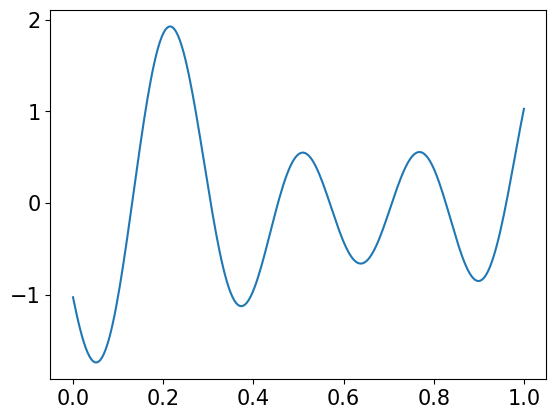

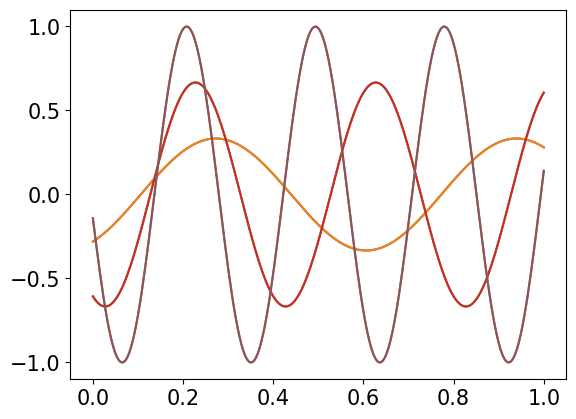

In [91]:
plt.plot(x, y)
plt.show()
for i in range(y_i.shape[0]):
    plt.plot(x, y_i[i])
    plt.plot(x, y_i[i])

In [92]:
from run_exp import *

num_iterations = 40000
batch_size = n_samples

In [93]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='gn-exact', 
)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_gn = train_model(state, x, y, num_iterations=num_iterations, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=batch_size
                                    )


  0%|                                                                              | 0/40000 [00:00<?, ?it/s]

Running gn-exact


100%|████████████████████████████████████████████████████████████████| 40000/40000 [1:04:41<00:00, 10.31it/s]


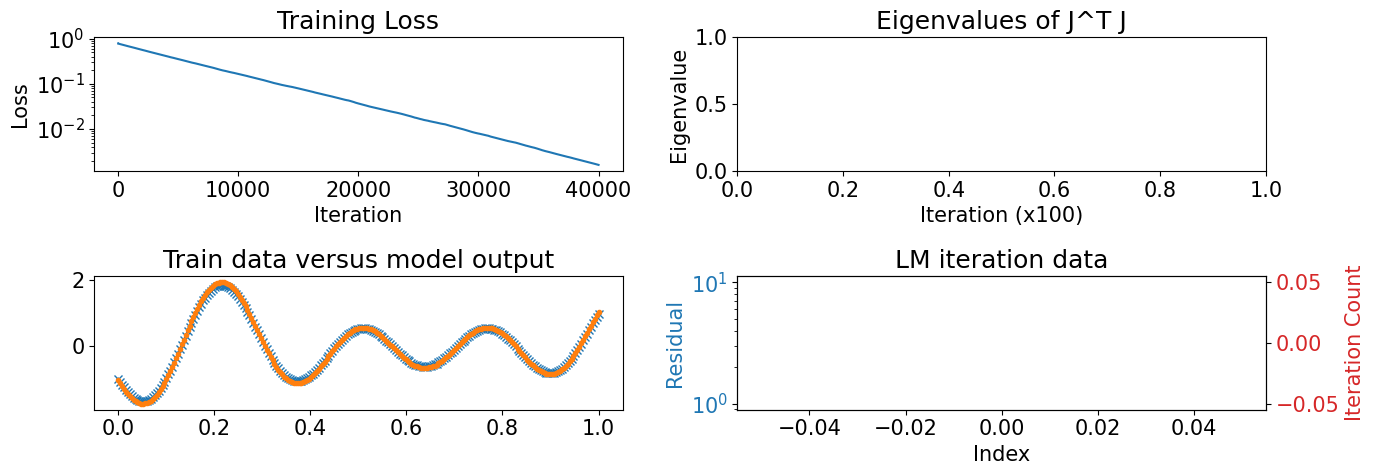

In [94]:
plot_results(state, metrics_history_gn, x, y)
plt.show()

/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_94040/332716754.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic', 10)


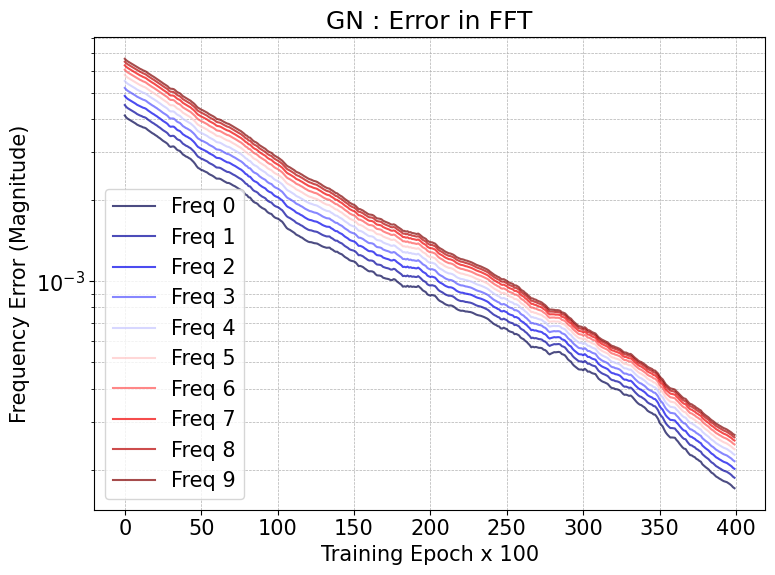

In [95]:

def perform_fft_anal(metrics_history, pad_factor=0):

    n_fft =  n_samples
    n = len(y)
    all_fft = []
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n_fft // 2]
        fft_err = jnp.abs(fft_err)
        all_fft.append(fft_err.flatten())
    
    all_fft = jnp.array(all_fft).T
    return  all_fft

def plot_freq_plots(metrics_history, title='', pad_factor=0):
    
    all_fft = perform_fft_anal(metrics_history, pad_factor=pad_factor)
    
    
    # Limit the number of frequencies to plot
    num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed
    cmap = cm.get_cmap('seismic', 10)
    
    plt.figure(figsize=(8, 6))
    for i in range(num_frequencies_to_plot):
        plt.semilogy(all_fft[i], label=f'Freq {i}', alpha=0.7, color=cmap(i/(num_frequencies_to_plot-1)))  # Use alpha for transparency
        # print(len(all_fft[i]))
        # print(all_fft[i])
    
    plt.title(f'{title} : Error in FFT')
    plt.xlabel('Training Epoch x 100')
    plt.ylabel('Frequency Error (Magnitude)')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_freq_plots(metrics_history_gn, title='GN', pad_factor=0)

In [96]:
model = MLP_1D(num_layers=2,hidden_dim=80)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_sgd = train_model(state, x, y, num_iterations=num_iterations, obtain_matrices=False, 
                                    lm_schedule=None, batch_size=batch_size
                                    )


100%|████████████████████████████████████████████████████████████████| 40000/40000 [00:18<00:00, 2128.02it/s]


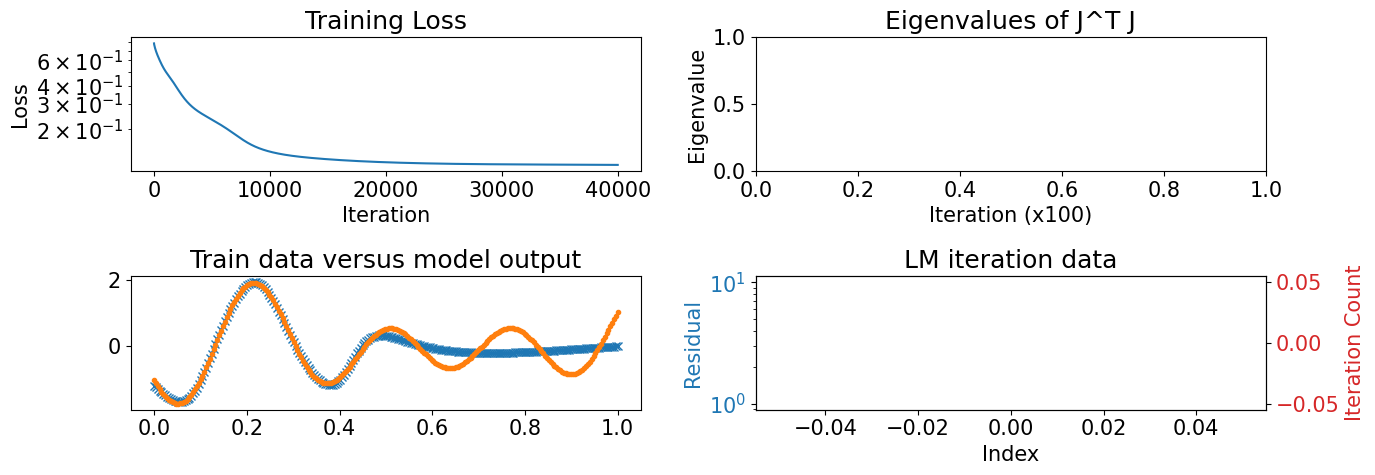

In [97]:
plot_results(state, metrics_history_sgd, x, y)
plt.show()


/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_94040/332716754.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic', 10)


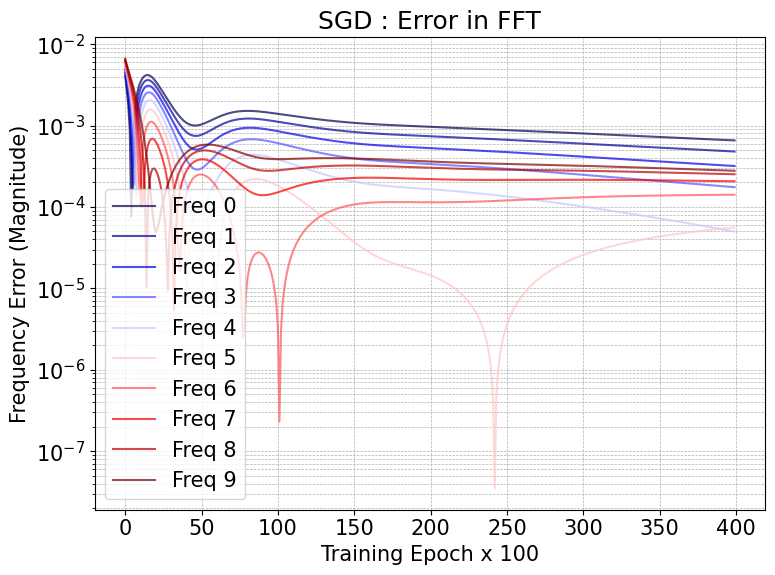

In [98]:

plot_freq_plots(metrics_history_sgd, title='SGD')

In [99]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_lm = train_model(state, x, y, num_iterations=num_iterations, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=batch_size
                                    )


  0%|                                                                    | 1/40000 [00:00<2:16:35,  4.88it/s]

Running smw


100%|██████████████████████████████████████████████████████████████████| 40000/40000 [10:24<00:00, 64.02it/s]


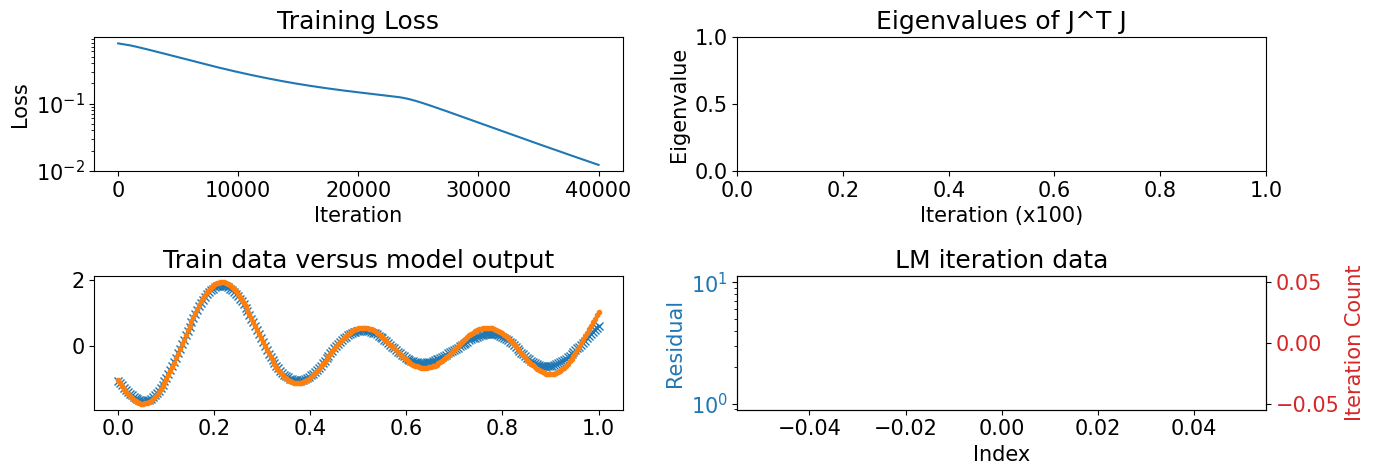

In [100]:
plot_results(state, metrics_history_lm, x, y)
plt.show()

/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_94040/332716754.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic', 10)


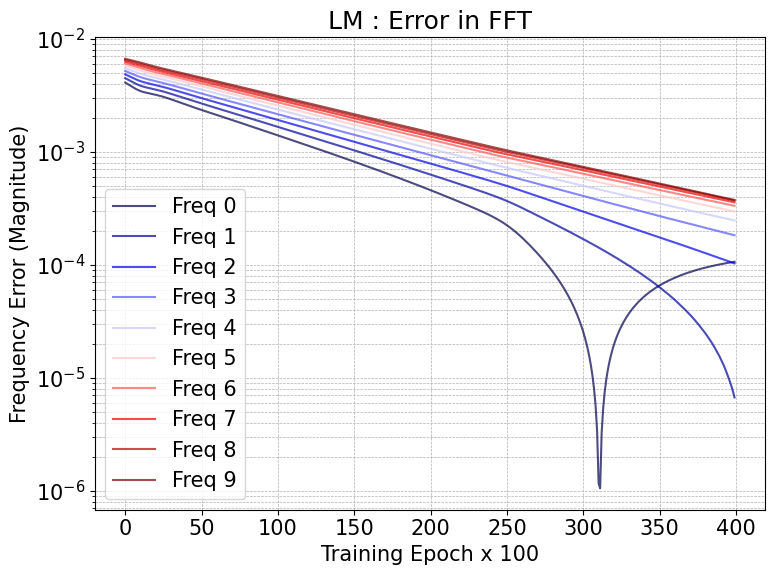

In [101]:
plot_freq_plots(metrics_history_lm, title='LM')

In [102]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=5e-1,
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_lm_5 = train_model(state, x, y, num_iterations=num_iterations, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=batch_size
                                    )


  0%|                                                                    | 1/40000 [00:00<1:50:53,  6.01it/s]

Running smw


100%|██████████████████████████████████████████████████████████████████| 40000/40000 [10:38<00:00, 62.67it/s]


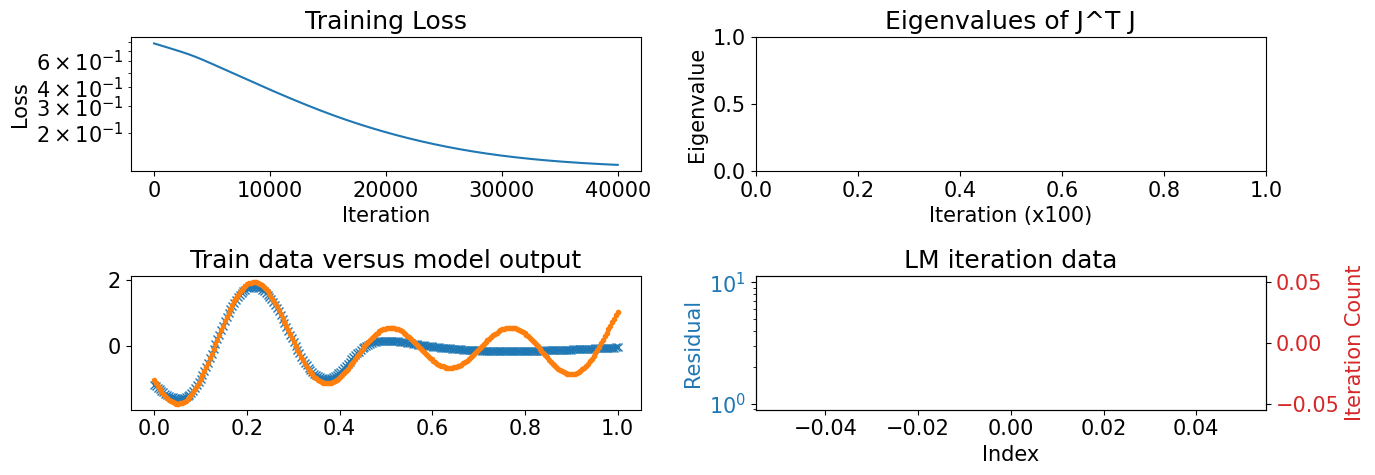

In [103]:
plot_results(state, metrics_history_lm_5, x, y)
plt.show()

/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_94040/332716754.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic', 10)


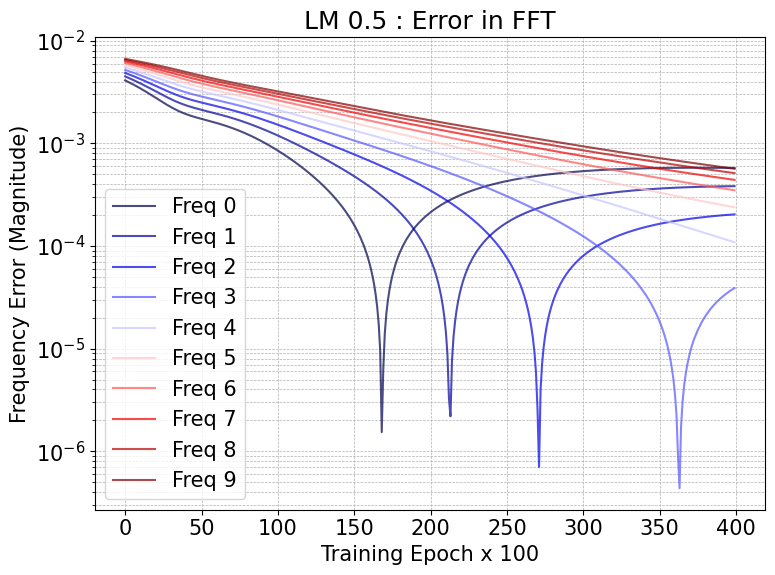

In [104]:
plot_freq_plots(metrics_history_lm_5, title='LM 0.5')

In [105]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_lm_01 = train_model(state, x, y, num_iterations=num_iterations, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=100
                                    )


  0%|                                                                              | 0/40000 [00:00<?, ?it/s]

Running smw


  0%|                                                                    | 1/40000 [00:00<5:17:13,  2.10it/s]

Running smw


100%|█████████████████████████████████████████████████████████████████| 40000/40000 [05:18<00:00, 125.72it/s]


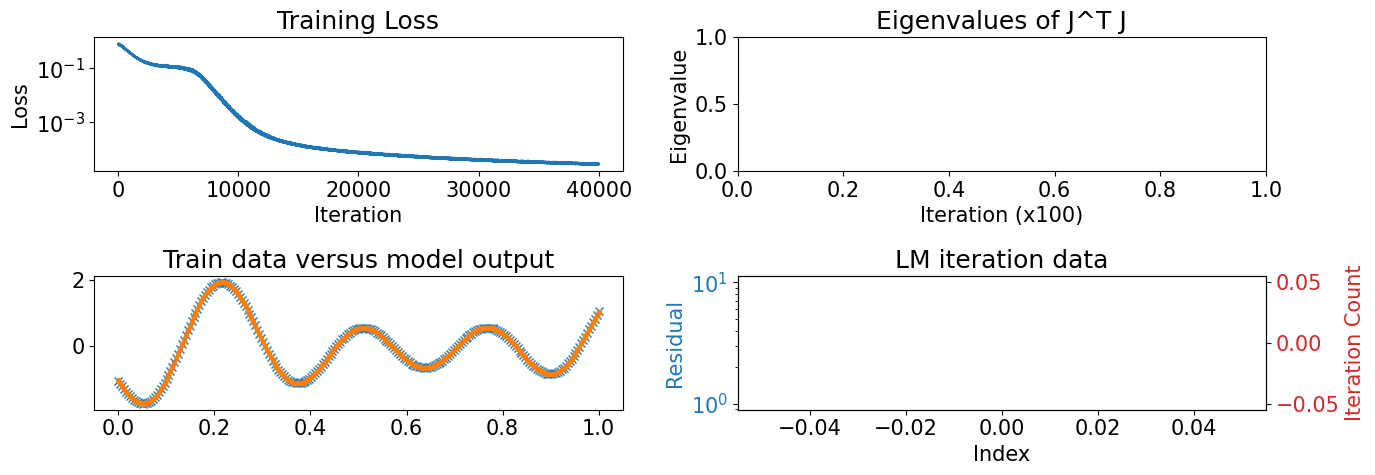

In [106]:
plot_results(state, metrics_history_lm_01, x, y)
plt.show()

/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_94040/332716754.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic', 10)


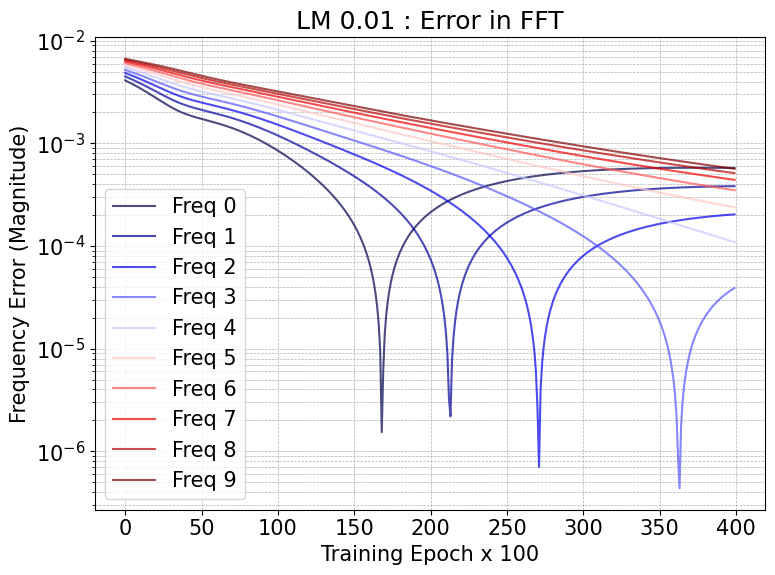

In [107]:
plot_freq_plots(metrics_history_lm_5, title='LM 0.01')

/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_94040/1445628385.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic', 10)


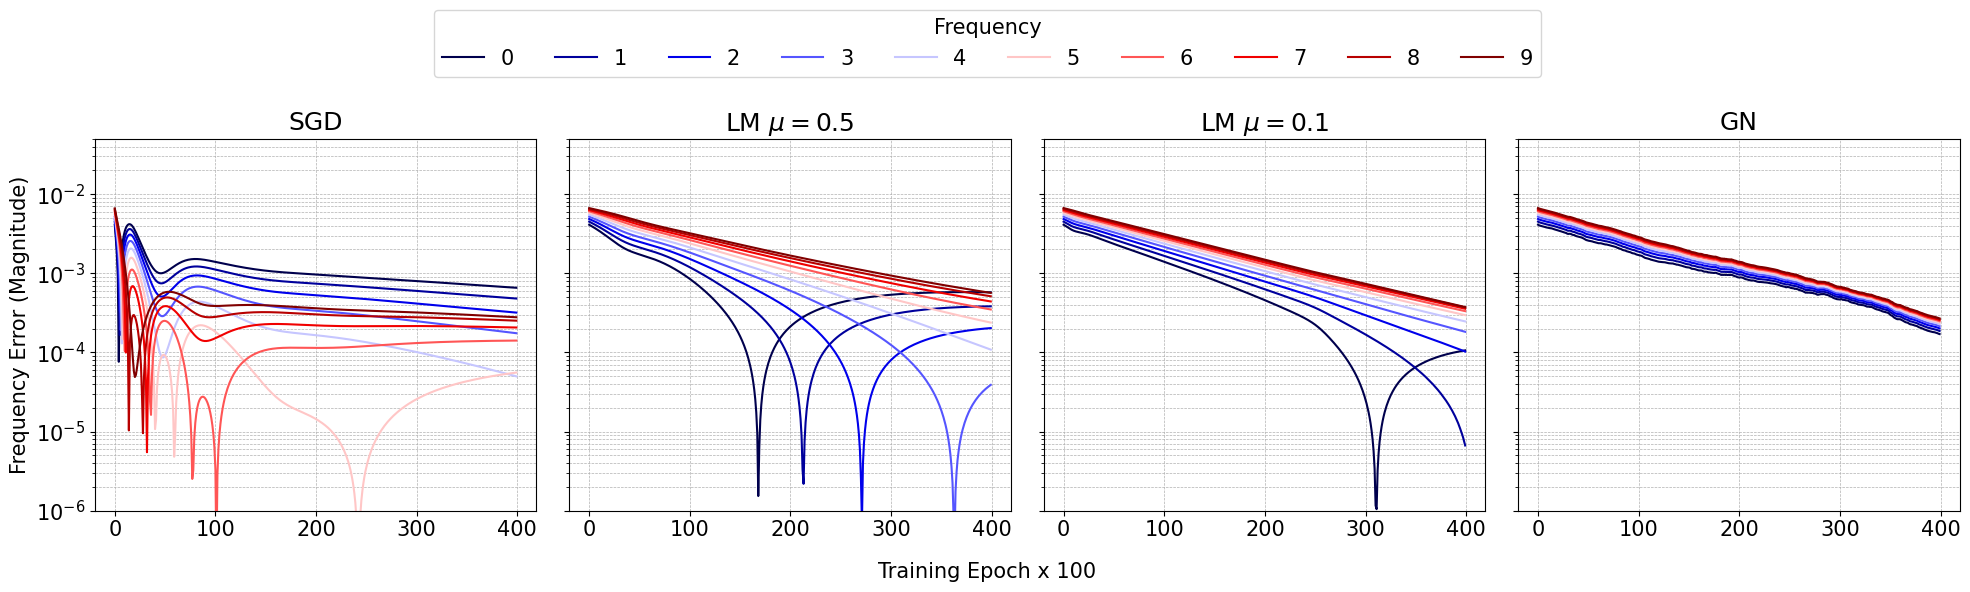

In [108]:
fig, subfigs = plt.subplots(1, 4, figsize=(20, 5), sharey='row')  # 1 row, 4 columns

metrics_histories = [metrics_history_sgd, metrics_history_lm_5, metrics_history_lm, metrics_history_gn]
names = ['SGD', r'LM $\mu=0.5$', r'LM $\mu=0.1$', 'GN']
cmap = cm.get_cmap('seismic', 10)

lines = []
labels = []
for idx, metrics_history in enumerate(metrics_histories):
    all_fft = perform_fft_anal(metrics_history, pad_factor=0)
    num_frequencies_to_plot = min(all_fft.shape[0], 10)

    for i in range(num_frequencies_to_plot):
        color = cmap(i / (num_frequencies_to_plot - 1))
        line, = subfigs[idx].semilogy(all_fft[i], label=f'{i}', alpha=1, color=color)
        if idx == 0:
            lines.append(line)
            labels.append(f'{i}')

    subfigs[idx].set_title(f'{names[idx]}')
    #subfigs[idx].set_xlabel('Training Epoch x 100')
    if idx == 0:
        subfigs[idx].set_ylabel('Frequency Error (Magnitude)')
    subfigs[idx].grid(True, which='both', linestyle='--', linewidth=0.5)
    subfigs[idx].set_ylim(1e-6, 5e-2)

# Add shared legend below all subplots
fig.legend(lines, labels, title="Frequency", loc='lower center', 
           ncol=10, bbox_to_anchor=(0.5, 1.001), fontsize=15, title_fontsize=15)
fig.text(0.5, 0.02, 'Training Epoch x 100', ha='center')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'ex_1_nsamples_{n_samples}.png')
plt.show()
